In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns  # Используем seaborn для улучшенной визуализации

     

In [8]:

df = pd.read_csv('DATA/toe/ДЗ_2_Прогнозирование_оценки_за_экз_по_ТОЭ.csv', header=0, engine='python')
df = df.drop(['Отметка времени'], axis=1)
df = df.drop(8, axis=0)
df = df.drop(['работа'], axis=1)
df = df.drop(['С какого раза'], axis=1)

df = df.fillna(value={"загрузка": 0,  "игры": 0})
df.replace({'нет': False, 'да': True}, inplace=True)
df.loc[df['игры'] >= 24, 'игры'] /= 62
df.loc[df['Где проживаете?'] == 'дома', 'Где проживаете?'] = 1
df.loc[df['Где проживаете?'] == 'общежитие 8', 'Где проживаете?'] = 2
df.loc[df['Где проживаете?'] == 'общежитие МСГ', 'Где проживаете?'] = 3
df.loc[df['Где проживаете?'] == 'oбщежитие 7', 'Где проживаете?'] = 4

df.loc[df['Гражданство'] == 'KAZ', 'Гражданство'] = 1
df.loc[df['Гражданство'] == 'RUS', 'Гражданство'] = 2
df.loc[df['Гражданство'] == 'BLR', 'Гражданство'] = 3

df['усталость'] -= 10
df['усталость'] *= -1
df = df.rename(columns={"усталость": "силы"})
df = df.fillna(df.mode().iloc[0])
df['ИДЗ'] = df['ИДЗ'].astype(int);
df['Оценка по физике семестре?'] = df['Оценка по физике семестре?'].astype(int);
df['лабораторныe ТОЭ'] = df['лабораторныe ТОЭ'].astype(int);
df['силы'] = df['силы'].astype(int);
df['Итоговая оценка'] = df['Итоговая оценка'].astype(int);
df

C:\Users\Malim\AppData\Local\Temp\ipykernel_23864\4063828227.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'нет': False, 'да': True}, inplace=True)
C:\Users\Malim\AppData\Local\Temp\ipykernel_23864\4063828227.py:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(df.mode().iloc[0])


,Итоговая оценка,Регулярность посещения,Оценка по физике в школе,Оценка по физике семестре?,ИДЗ,лабораторныe ТОЭ,конспект,Выходили к доске?,Оценка за кр,загрузка,Где проживаете?,Есть кот дома?,Есть родной брат/сестра?,Гражданство,игры,стипендия,ментальное здоровье,силы
0,5,75,5,5,5,5,True,True,5,0.00,2,False,True,1,10.000000,True,9,9
1,3,75,4,5,4,5,True,False,3,0.00,1,False,True,2,20.000000,False,7,4
2,3,75,5,4,5,5,True,False,5,0.25,1,True,True,2,2.709677,True,7,7
3,3,75,5,4,4,4,False,False,4,0.50,2,False,True,1,18.000000,False,7,8
4,4,100,4,3,4,5,False,False,5,0.00,1,False,True,2,20.000000,False,10,5
5,3,75,4,3,3,5,True,False,3,0.50,1,False,False,2,2.000000,False,4,2
6,3,25,3,3,3,3,False,False,3,0.50,1,True,True,2,1.000000,False,1,2
7,3,25,5,3,5,5,False,True,5,0.00,4,False,True,3,2.000000,False,10,10
9,5,50,5,5,5,5,True,True,5,0.00,1,False,False,1,8.000000,True,6,2
10,4,100,4,5,5,4,True,False,5,0.00,1,False,True,2,0.000000,True,9,3


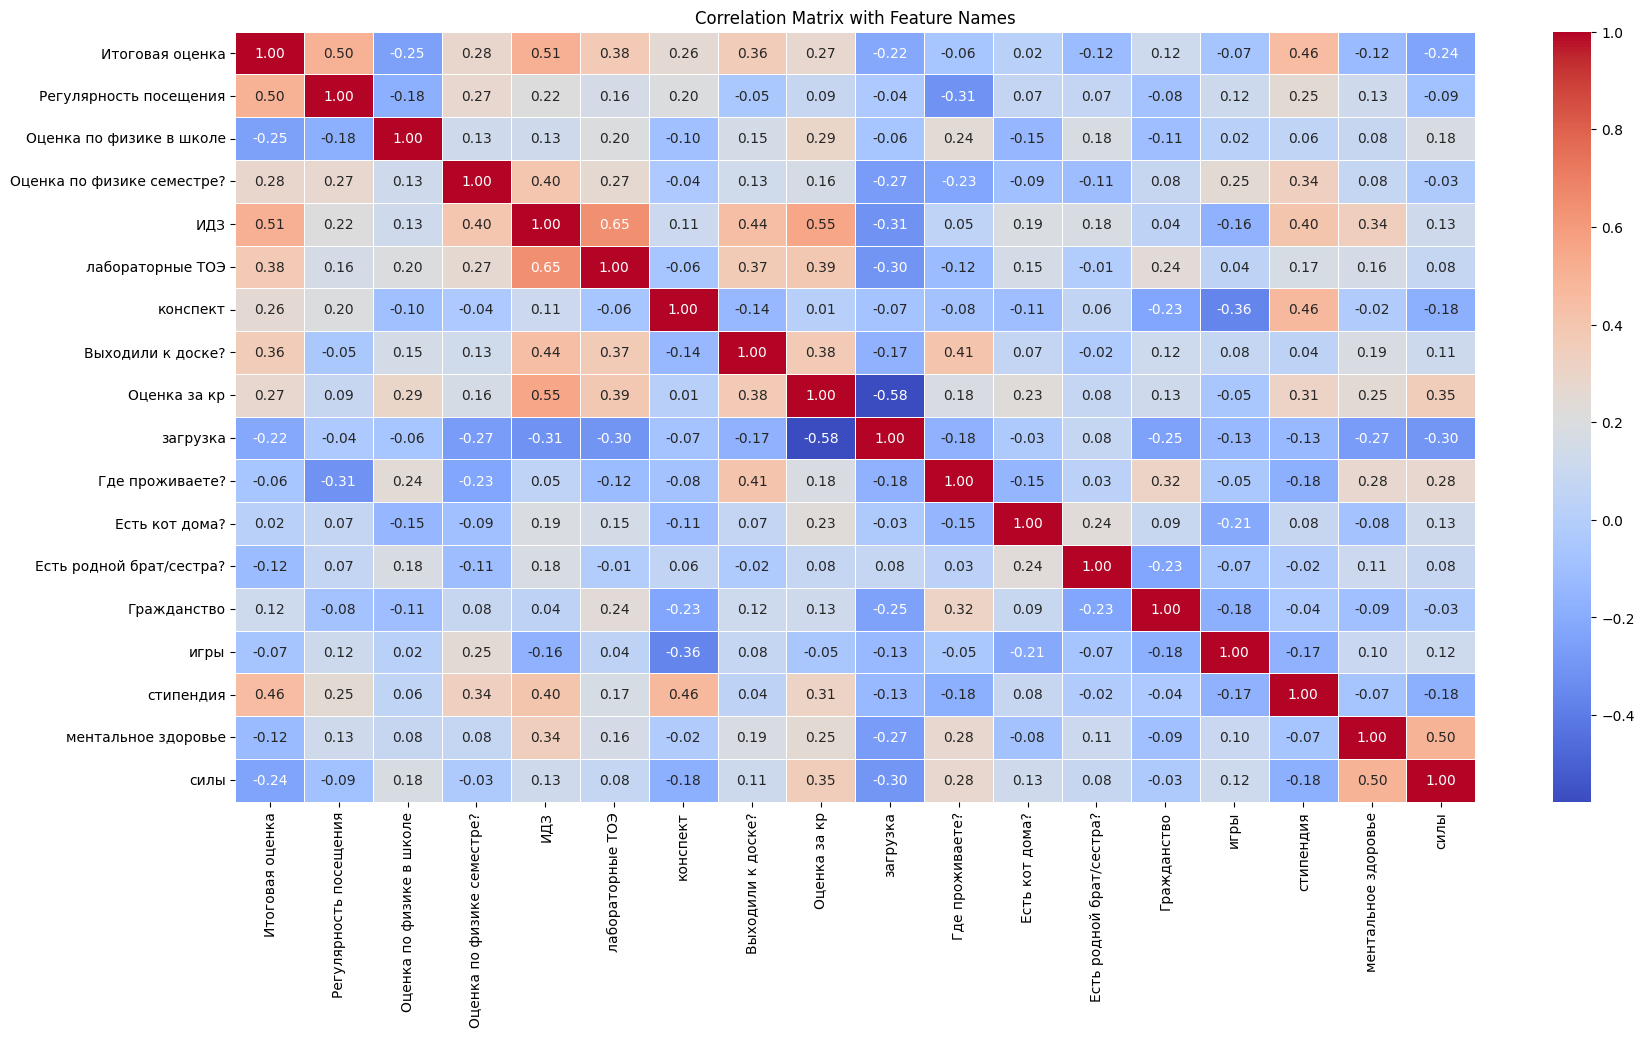

In [9]:
correlation_matrix = df.corr(numeric_only =  True)

plt.figure(figsize=(20, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix with Feature Names')
plt.show()


In [277]:
df.head()

,Итоговая оценка,Регулярность посещения,Оценка по физике в школе,Оценка по физике семестре?,ИДЗ,лабораторныe ТОЭ,конспект,Выходили к доске?,Оценка за кр,загрузка,Где проживаете?,Есть кот дома?,Есть родной брат/сестра?,Гражданство,игры,стипендия,ментальное здоровье,силы
0,5,75,5,5,5,5,True,True,5,0.00,2,False,True,1,10.000000,True,9,9
1,3,75,4,5,4,5,True,False,3,0.00,1,False,True,2,20.000000,False,7,4
2,3,75,5,4,5,5,True,False,5,0.25,1,True,True,2,2.709677,True,7,7
3,3,75,5,4,4,4,False,False,4,0.50,2,False,True,1,18.000000,False,7,8
4,4,100,4,3,4,5,False,False,5,0.00,1,False,True,2,20.000000,False,10,5


In [11]:
X = df.drop('Итоговая оценка', axis=1)
y = df['Итоговая оценка']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)



LinearRegression()

In [15]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R² Score: {r2}')

Mean Squared Error: 1.2997274029299035
R² Score: -1.312750231684093


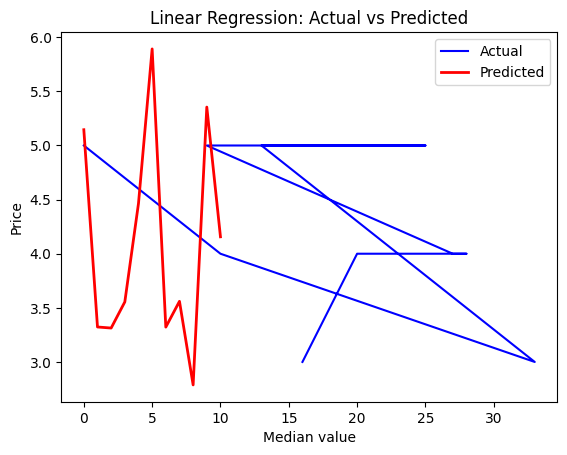

In [ ]:
plt.plot(y_test, color='blue', label='Actual')
plt.plot(y_pred, color='red', linewidth=2, label='Predicted')
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Median value')
plt.ylabel('Price')
plt.legend()
plt.show()

нуу да  конечено легче предсказать какую оценку вы не получите..

In [28]:
import joblib

model = LinearRegression()
model.fit(df.drop("Итоговая оценка", axis=1), df["Итоговая оценка"])

joblib.dump(model, 'toe.pkl')

['toe.pkl']